# VISION on the Visium mouse colon dataset

This notebook demonstrates a standard, standalone VISION pipeline (gene signature scoring and graph autocorrelation) using `scviva.tools.vision.VisionAnalysis`.

**Dataset:** the same mouse colon 10x Visium dataset (Parigi et al.) used in [`Visium_colon_Harreman_pipeline`](Visium_colon_Harreman_pipeline.ipynb), loaded via `load_visium_mouse_colon_dataset()`. For how VISION and Harreman's Hotspot-equivalent gene modules intersect on this same dataset, see that other tutorial.

**Gene signatures:** KEGG metabolic pathway gene sets, fetched from the same hosted URL (`exampledata.scverse.org`) used in that other tutorial.

**Pipeline:**
1. Load the dataset and apply minimal per-sample gene filtering.
2. `VisionAnalysis.setup(compute_neighbors_on_key="spatial_unrolled")` — VISION builds and owns its own spot neighbor graph from the (unrolled) spatial coordinates.
3. `va.load_signatures()` / `va.compute_signatures()` — score every spot against the KEGG pathways and test each pathway's spatial autocorrelation.
4. `va.compute_differential_expression()` — test which pathways differ most between the two regeneration timepoints (Day 0 vs Day 14).
5. Spatial visualization of the most autocorrelated KEGG pathway.
6. Further VISION capabilities beyond the core pipeline: spatial autocorrelation of non-signature metadata, signature clustering, gene importance, one-vs-one differential expression, and the `results` typed accessor (sections 7 onward).

## 0 · Imports

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import requests
import scanpy as sc

import scviva

from scviva.tools.harreman.datasets import load_visium_mouse_colon_dataset
from scviva.tools.vision import VisionAnalysis


In [2]:
try:
    import rapids_singlecell as rsc

    print("RAPIDS SingleCell is installed and can be imported")
    HAS_RSC = True
except ImportError:
    HAS_RSC = False

In [3]:
scviva.settings.seed = 0
print("Last run with scviva-tools version:", scviva.__version__)

Seed set to 0


Last run with scviva-tools version: 0.1.6


## 1 · Load the Visium mouse colon dataset

In [4]:
adata = load_visium_mouse_colon_dataset()
print(adata)

AnnData object with n_obs × n_vars = 6168 × 31053
    obs: 'in_tissue', 'array_row', 'array_col', 'cond', 'id', 'row', 'col', 'layer', 'ord', 'dist', 'spot', 'pixel_x', 'pixel_y'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'cond_colors'
    obsm: 'spatial', 'spatial_unrolled'
    layers: 'counts', 'log_norm', 'normalized'


In [5]:
# Minimal per-sample gene filtering: keep a gene if it passes the expression
# threshold in ANY sample (union across "cond" == "Day 0"/"Day 14"), matching
# the preprocessing in Visium_colon_Harreman_pipeline.ipynb.
sample_col = "cond"
n_genes_expr = 50
genes_to_keep = np.zeros(adata.shape[1], dtype=bool)

for sample in adata.obs[sample_col].unique():
    adata_sample = adata[adata.obs[sample_col] == sample]
    expressed = np.array((adata_sample.X > 0).sum(axis=0)).flatten()
    genes_to_keep |= expressed >= n_genes_expr

adata = adata[:, genes_to_keep].copy()

# Drop obs columns that are purely technical bookkeeping (array/pixel
# coordinates, per-spot barcodes, a QC flag that's constant after filtering to
# in-tissue spots) so the VISION differential-expression step below only
# compares signatures across the biologically meaningful metadata: "cond"
# (regeneration day), "layer", "ord" and "dist" (spatial axes).
adata.obs = adata.obs.drop(
    columns=["in_tissue", "array_row", "array_col", "id", "row", "col", "spot", "pixel_x", "pixel_y"]
)
print(adata)

AnnData object with n_obs × n_vars = 6168 × 13967
    obs: 'cond', 'layer', 'ord', 'dist'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'cond_colors'
    obsm: 'spatial', 'spatial_unrolled'
    layers: 'counts', 'log_norm', 'normalized'


## 2 · VISION setup: spatial neighbor graph

`VisionAnalysis.setup()` builds and owns its own KNN graph directly from `compute_neighbors_on_key="spatial_unrolled"` (Parigi et al.'s common linear coordinate across conditions).


In [6]:
va = VisionAnalysis(adata, norm_data_key="log_norm")
va.setup(compute_neighbors_on_key="spatial_unrolled", num_neighbors=5)
print(f"obsp['weights'] shape: {adata.obsp['weights'].shape}, nnz: {adata.obsp['weights'].nnz}")

INFO     Building KNN graph: n_cells=6168, K=5.                                                                    
INFO     KNN weight matrix built — nnz=30840.                                                                      
INFO     KNN weights stored in adata.obsp['weights'] — shape (6168, 6168).                                         
INFO     VisionAnalysis: setup complete.                                                                           
obsp['weights'] shape: (6168, 6168), nnz: 30840


## 3 · Tissue sections at a glance

A quick look at the two conditions (regeneration Day 0 vs Day 14) across the
unrolled tissue before diving into signature analysis.


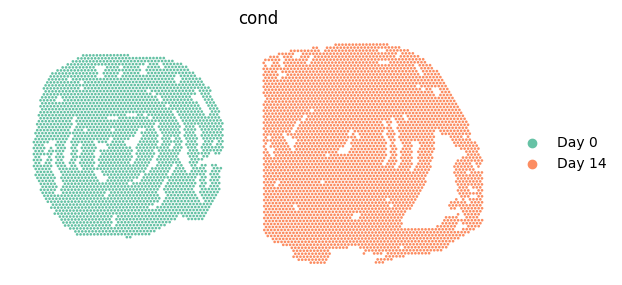

In [7]:
sc.pl.spatial(adata, color="cond", spot_size=80, frameon=False)

## 4 · Load KEGG metabolic signatures and score them (`va`)

Gene signatures here are KEGG metabolic pathway gene sets, fetched from the same hosted URL as `Visium_colon_Harreman_pipeline.ipynb`. `compute_signatures()` both scores every spot against each pathway and tests each pathway's autocorrelation against the neighbor graph built in step 2.

In [8]:
resp = requests.get("https://exampledata.scverse.org/scvi-tools/KEGG_metab_m.json")
resp.raise_for_status()
kegg_metab = resp.json()
print(f"KEGG metabolic pathways available: {len(kegg_metab)}")

va.load_signatures(dicts=[kegg_metab], min_signature_genes=5, sig_gene_threshold=0.001)
print(f"signatures loaded: {adata.varm['signatures'].shape[1]}")

va.compute_signatures()
print(f"vision_signatures: {adata.obsm['vision_signatures'].shape}")

autocorr_sig = adata.uns["vision_signature_scores"].sort_values("c_prime", ascending=False)
print("\nTop 10 most autocorrelated KEGG pathways:")
print(autocorr_sig.head(10).round(4).to_string())

KEGG metabolic pathways available: 69
signatures loaded: 69
INFO     Computing signatures for each cell...                                                                     
WARNING  PyTorch path failed (The NVIDIA driver on your system is too old (found version 12020). Please update your
         GPU driver by downloading and installing a new version from the URL:                                      
         http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch  
         version that has been compiled with your version of the CUDA driver.); falling back to scipy sparse.      
INFO     Signatures computed in 1.243 s.                                                                           
INFO     Computing Geary's C for all the signatures...                                                             
INFO     Generating the null distribution...                                                                       
INFO     Com

## 5 · Differential expression: Day 0 vs Day 14

`compute_differential_expression()` runs a one-vs-all comparison of every KEGG pathway score across each categorical `adata.obs` column: here `"cond"` (condition; Day 0 or Day 14) is the only one left after the column pruning in step 1.

In [10]:
va.compute_differential_expression()

cond_diff = adata.uns["vision_signature_differential"]["cond"]
for group, df in cond_diff.groupby("group"):
    top = df[df['pvals_adj'] < 0.05].sort_values("logfoldchanges", ascending=False).head(5)
    print(f"\nTop 5 KEGG pathways up in {group} (vs rest):")
    print(top[["names", "logfoldchanges", "pvals_adj"]].to_string(index=False))

INFO     Computing observation scores...                                                                           
INFO     Finished computing observation scores in 1.280 seconds.                                                   

Top 5 KEGG pathways up in Day 0 (vs rest):
                        names  logfoldchanges    pvals_adj
        PYRIMIDINE METABOLISM        3.304632 3.221349e-16
INOSITOL PHOSPHATE METABOLISM        1.877165 5.321832e-44
            PURINE METABOLISM        0.892874 3.285053e-11
           LYSINE DEGRADATION        0.661723 7.243375e-95
       ETHER LIPID METABOLISM        0.615029 1.213165e-18

Top 5 KEGG pathways up in Day 14 (vs rest):
                             names  logfoldchanges     pvals_adj
       ARACHIDONIC ACID METABOLISM        2.071414 2.615061e-277
     GLYCOSAMINOGLYCAN DEGRADATION        1.167843  6.759425e-18
             O GLYCAN BIOSYNTHESIS        0.874816  7.707897e-27
CYSTEINE AND METHIONINE METABOLISM        0.846627  1.324726e-11


## 6 · Spatial visualization of the top autocorrelated pathway

Rather than assume a specific expected biological pattern up front, we let the data pick the most spatially-autocorrelated KEGG pathway from the analysis above and plot it directly across the tissue.

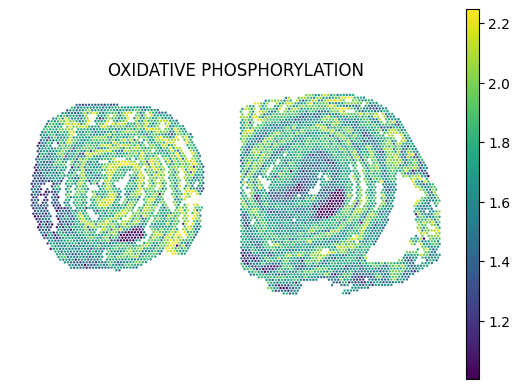

In [11]:
top_sig = autocorr_sig.index[0]
adata.obs["top_kegg_pathway_score"] = adata.obsm["vision_signatures"][top_sig].values

sc.pl.spatial(
    adata,
    color="top_kegg_pathway_score",
    spot_size=80,
    frameon=False,
    vmin="p1",
    vmax="p99",
    cmap="viridis",
    title=top_sig,
)

## 7 · Spatial autocorrelation of metadata covariates (`layer`, `ord`, `dist`)

`layer`, `ord`, and `dist` describe the tissue's own spatial axes (layer identity, position along the unrolled axis, distance from the tissue surface). The question we ask here is as follows: do these already-known spatial variables show graph autocorrelation the same way the KEGG pathway scores do?

In [12]:
obs_scores = adata.uns["vision_obs_df_scores"]
print("Autocorrelation of adata.obs columns (c_prime = 1 - Geary's C for numeric, Cramer's V for categorical):")
print(obs_scores.sort_values("c_prime", ascending=False).round(4).to_string())

Autocorrelation of adata.obs columns (c_prime = 1 - Geary's C for numeric, Cramer's V for categorical):
                 c_prime   pvals     fdr
ord               1.0000  0.0003  0.0031
cond              0.9997  0.0000  0.0000
VISION_Clusters   0.9884  0.0000  0.0000
layer             0.9876  0.0003  0.0031
dist              0.9558  0.0003  0.0031


## 8 · Signature clustering: grouping KEGG pathways by spatial pattern

`compute_differential_expression()` also clusters signatures into groups with similar spatial score patterns (`adata.uns["vision_sig_clusters"]`), via a BIC-selected Gaussian mixture over signatures that pass a significance gate (FDR < 0.05 and Geary's C' > 0.2). A newick-format dendrogram of all signatures (regardless of significance) is also available (`adata.uns["vision_dendrogram"]`).

In [13]:
sig_clusters = pd.Series(adata.uns["vision_sig_clusters"], name="cluster")
print(f"{sig_clusters.nunique()} signature cluster(s) across {len(sig_clusters)} KEGG pathways")
print(sig_clusters.value_counts().sort_index())

top_sig_cluster = sig_clusters[top_sig]
same_cluster = [s for s in sig_clusters[sig_clusters == top_sig_cluster].index if s != top_sig]
print(f"\n'{top_sig}' is in cluster {top_sig_cluster}, alongside {len(same_cluster)} other pathway(s):")
print(same_cluster[:10])

12 signature cluster(s) across 69 KEGG pathways
cluster
1      1
2      1
3      3
4      3
7      3
8      6
9      8
10     1
11     2
12     1
13     1
15    39
Name: count, dtype: int64

'OXIDATIVE PHOSPHORYLATION' is in cluster 9, alongside 7 other pathway(s):
['AMINO SUGAR AND NUCLEOTIDE SUGAR METABOLISM', 'CITRATE CYCLE TCA CYCLE', 'FRUCTOSE AND MANNOSE METABOLISM', 'GLYCEROLIPID METABOLISM', 'GLYCOLYSIS GLUCONEOGENESIS', 'PENTOSE PHOSPHATE PATHWAY', 'PYRUVATE METABOLISM']


## 9 · Reusing already-loaded signatures (`attach_signatures`)

`load_signatures()` (section 4) both parses a GMT/dict source *and* stores the result in `adata.varm`. If signatures were already loaded (by an earlier `VisionAnalysis` session on the same `adata`, or by calling `scviva.tools.vision.tools.signature.load_signatures` directly) re-parsing the source is redundant. `attach_signatures()` just points a new session at the existing `adata.varm` entry. Here we use it to re-score the same KEGG pathways against a *different* expression layer (`"normalized"` instead of `"log_norm"`) without re-fetching or re-parsing the KEGG gene sets.

In [14]:
va_reuse = VisionAnalysis(adata, norm_data_key="normalized")
va_reuse.setup(compute_neighbors_on_key="spatial_unrolled", num_neighbors=5)
va_reuse.attach_signatures()  # reuses the "signatures" `va` already loaded from KEGG
va_reuse.compute_signatures()  # overwrites adata's vision_signatures/vision_signature_scores

autocorr_reuse = adata.uns["vision_signature_scores"].sort_values("c_prime", ascending=False)
print("Top 5 KEGG pathways when scored on the 'normalized' layer instead of 'log_norm':")
print(autocorr_reuse.head(5).round(4).to_string())

INFO     Building KNN graph: n_cells=6168, K=5.                                                                    
INFO     KNN weight matrix built — nnz=30840.                                                                      
INFO     KNN weights stored in adata.obsp['weights'] — shape (6168, 6168).                                         
INFO     VisionAnalysis: setup complete.                                                                           
INFO     Computing signatures for each cell...                                                                     
WARNING  log2p1: input does not look log-transformed (large and/or integer-valued values found) -- applying log2(x 
         + 1) internally. VISION expects scaled/library-size-normalized but NOT log-transformed expression data;   
         pass check_log_transformed=False to always apply this transform without the check, or pre-transform your  
         data and this message will stop appearing.                     

## 10 · Direct one-vs-one gene differential expression (`compute_one_vs_one_de`)

`compute_differential_expression()` (section 5) tested *signatures*
one-vs-all across `"cond"`. `compute_one_vs_one_de()` complements it at the
*gene* level: a direct Wilcoxon test of every gene between two named groups
of an `adata.obs` column, returning a scanpy-style results `DataFrame`
rather than writing into `adata.uns`.


In [15]:
de_day0_vs_day14 = va.compute_one_vs_one_de(key="cond", group1="Day 0", group2="Day 14")
print("Top genes up in Day 0 vs. Day 14 (one-vs-one Wilcoxon):")
print(de_day0_vs_day14.sort_values("scores", ascending=False).head(5).to_string(index=False))

Top genes up in Day 0 vs. Day 14 (one-vs-one Wilcoxon):
 names   scores  logfoldchanges  pvals  pvals_adj
 Mptx1 1.278292        2.802165    0.0        0.0
  Igha 1.274261        2.082730    0.0        0.0
  Igkc 1.208995        1.251213    0.0        0.0
Jchain 1.206805        1.742756    0.0        0.0
 Neat1 1.151869        0.786609    0.0        0.0


## 11 · Inspecting a signature's genes and their expression

`get_genes_by_signature()` lists the genes making up a signature (with
their +/-1 sign), and `get_gene_expression()` pulls dense per-cell
expression for arbitrary genes from whichever layer the session is scoring
from. Together they let you drill from "this pathway is spatially
autocorrelated" (section 4/6) down to the individual genes driving it.


In [16]:
top_sig_genes = va.get_genes_by_signature(top_sig)
print(f"'{top_sig}' has {len(top_sig_genes)} genes:")
print(top_sig_genes.head(10))

expr = va.get_gene_expression(top_sig_genes.index[:3].tolist())
print(f"\nDense expression for the top 3 genes, shape: {expr.shape}")

'OXIDATIVE PHOSPHORYLATION' has 100 genes:
           0
Atp6v1h  1.0
Cox5b    1.0
Ndufb3   1.0
Ndufs1   1.0
Ndufa10  1.0
Sdhc     1.0
Ndufs2   1.0
Ndufa8   1.0
Ndufs3   1.0
Cox4i2   1.0

Dense expression for the top 3 genes, shape: (6168, 3)


## 12 · Gene importance: which genes drive a signature's score

`get_genes_by_signature()` (section 11) lists a signature's member genes and their +/-1 sign, but not how much each gene actually drives the signature's score. `adata.uns["vision_gene_importance"]` ranks each signature's genes by their covariance with the signature score across spots, mirroring R VISION's own `evalSigGeneImportance`/`evalSigGeneImportanceSparse`.

In [17]:
gene_importance = adata.uns["vision_gene_importance"][top_sig]
print(f"Gene importance for '{top_sig}' ({len(gene_importance)} genes):")
print(gene_importance.sort_values("importance", ascending=False).head(10))

Gene importance for 'OXIDATIVE PHOSPHORYLATION' (100 genes):
         importance  sign
mt-Co1     0.100414   1.0
mt-Co2     0.084415   1.0
mt-Atp6    0.068250   1.0
Cox6c      0.062778   1.0
Uqcrq      0.060066   1.0
mt-Co3     0.058970   1.0
Cox5b      0.056180   1.0
Cox6b1     0.055799   1.0
Uqcr10     0.054401   1.0
mt-Cytb    0.053591   1.0


## 13 · The lower-level `rank_genes_groups` function

`compute_one_vs_one_de()` (section 10) and `compute_differential_expression()` (section 5) both wrap `scviva.tools.vision.rank_genes_groups` (VISION's own Wilcoxon rank-sum implementation; extended from scanpy's to also report AUC). It's lazily imported (not eagerly pulled in when you `import scviva.tools.vision`) so it's available as a standalone function when you want gene-level one-vs-rest DE without a `VisionAnalysis` session at all.

In [18]:
from scviva.tools.vision import rank_genes_groups

rank_genes_groups(
    adata, groupby="cond", method="wilcoxon", layer="log_norm", use_raw=False, key_added="rank_genes_groups_cond"
)
de_all = sc.get.rank_genes_groups_df(adata, "Day 14", key="rank_genes_groups_cond")
print("Top genes up in Day 14 (one-vs-rest Wilcoxon, called directly):")
print(de_all.sort_values("scores", ascending=False).head(5).to_string(index=False))

Top genes up in Day 14 (one-vs-rest Wilcoxon, called directly):
 names   scores  logfoldchanges         pvals     pvals_adj
 Krt13 1.475519        5.989747 9.203821e-306 1.168634e-302
Tmsb10 1.473530        0.573227 1.922009e-301 2.237059e-298
Tmsb4x 1.466570        0.558383 1.432214e-286 1.333582e-283
Tmbim6 1.466198        0.610083 8.720909e-286 7.612808e-283
 Plac8 1.462923        0.798812 6.271527e-279 5.152613e-276


## 14 · Putting it together: the `va.results` typed accessor

Every VISION result above was reached via `adata.uns["vision_..."]`/`adata.obsm["vision_signatures"]` directly. `va.results` gives the same information as one typed `VisionResults` object, which is often more convenient once several analysis steps have run, and `repr(va)` gives a quick one-line summary of which pipeline steps a session has completed.

In [19]:
print(f"repr(va): {va!r}\n")

results = va.results
print(f"Signature scores:          {results.signature_scores.shape}")
print(f"Signature autocorrelation: {results.signature_autocorrelation.shape}")
print(f"Meta/obs-column scores:    {results.obs_df_scores.shape}")
print(f"Signature clusters:        {len(results.signature_clusters)} entries")
print(f"Gene importance:           {len(results.gene_importance)} signature(s) scored")

repr(va): VisionAnalysis(is_set_up=True, completed_steps=['compute_differential_expression', 'compute_signatures', 'setup'])

Signature scores:          (6168, 69)
Signature autocorrelation: (69, 3)
Meta/obs-column scores:    (5, 3)
Signature clusters:        69 entries
Gene importance:           69 signature(s) scored


## 15 · Takeaways

- `VisionAnalysis(adata, norm_data_key="log_norm")` ran the full VISION pipeline standalone on the Visium mouse colon dataset used in [`Visium_colon_Harreman_pipeline`](Visium_colon_Harreman_pipeline.ipynb), from a single hosted dataset download plus a hosted KEGG gene-set file.
- `compute_differential_expression()` surfaced KEGG pathways that significantly differ between the two regeneration timepoints, purely from per-cell signature scores (no gene-module discovery step required).
- See [`Visium_colon_Harreman_pipeline`](Visium_colon_Harreman_pipeline.ipynb) for how these same VISION signatures intersect with Harreman's Hotspot-equivalent gene modules via `ha.vs.integrate_vision_hotspot_results()`.
- `compute_obs_df_scores()`'s output (section 7) tested the tissue's own spatial-axis metadata (`layer`, `ord`, `dist`) for the same kind of graph autocorrelation used for KEGG pathways.
- Signature clustering (section 8) grouped KEGG pathways by spatial-pattern similarity, using the BIC-selected Gaussian mixture.
- `attach_signatures()` (section 9) re-scored the same KEGG pathways on a different expression layer without re-parsing the gene sets.
- `compute_one_vs_one_de()` (section 10) and the standalone `rank_genes_groups()` (section 13) gave direct, gene-level Wilcoxon tests independent of the signature-level differential expression in section 5.
- `get_genes_by_signature()` and `get_gene_expression()` (section 11) drilled from a signature's autocorrelation score down to its individual member genes; gene importance (section 12) ranked those genes by how much each one drives the signature's score.
- `va.results` and `repr(va)` (section 14) gave a typed, at-a-glance view over everything computed above.